Logistic Regression is being optimized...
KNN is being optimized...
Decision Tree is being optimized...
Random Forest is being optimized...
AdaBoost is being optimized...
XGBoost is being optimized...


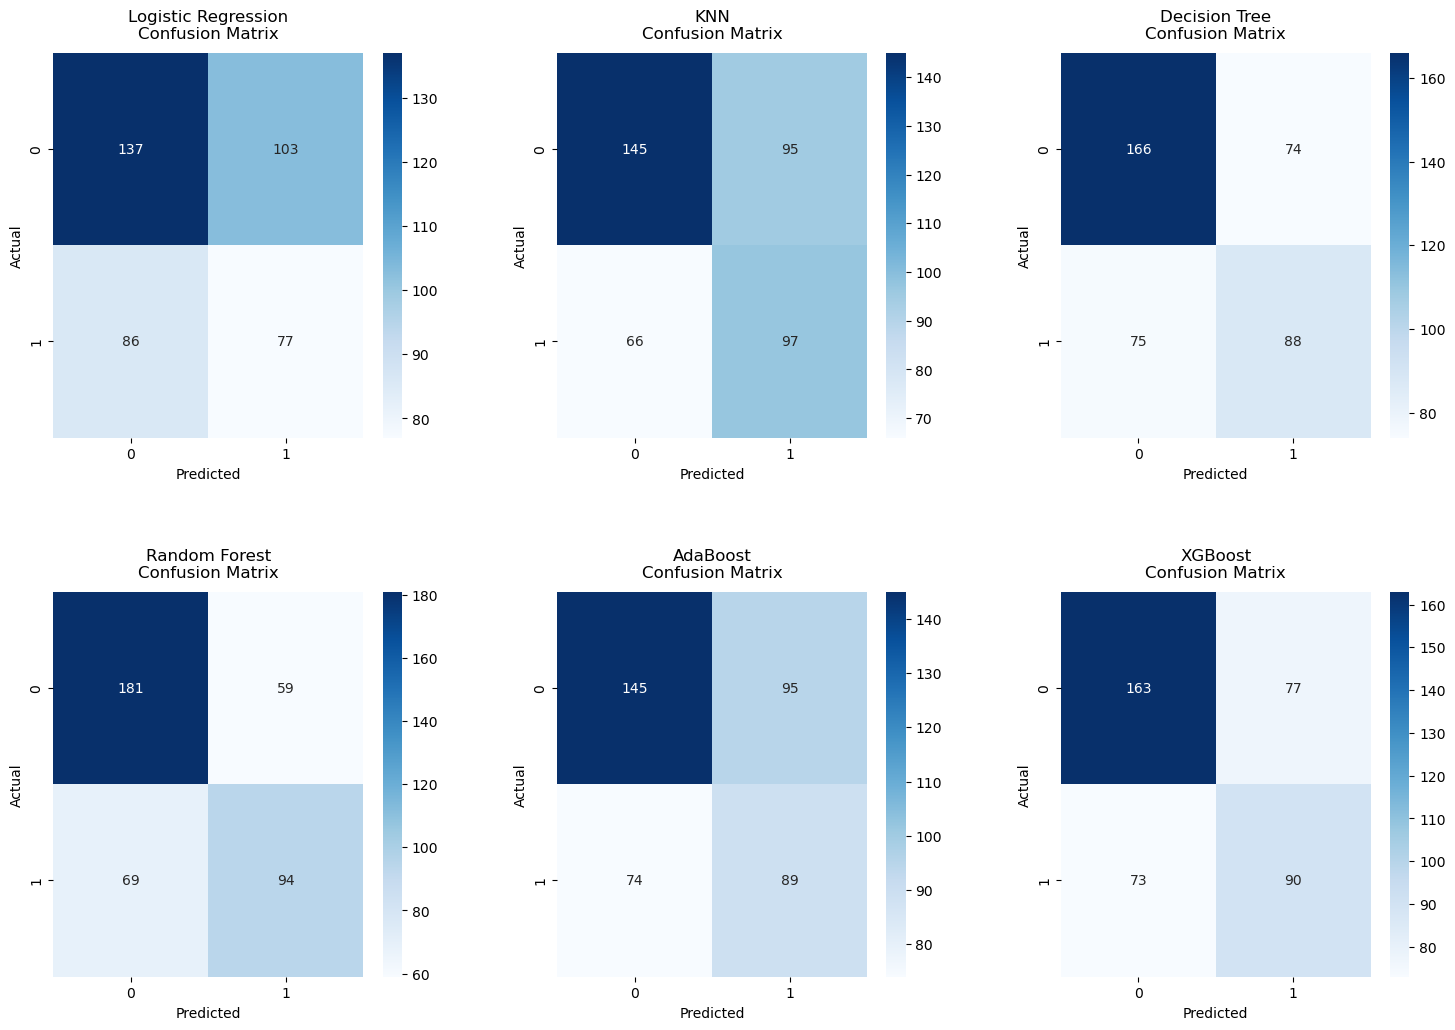

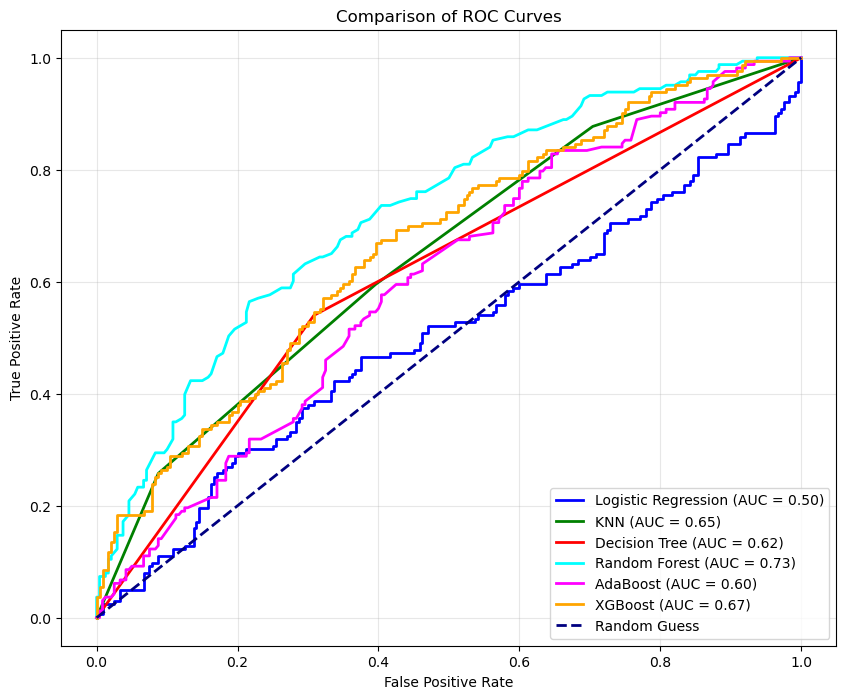

,Model,Accuracy,Recall,F1-Score
3,Random Forest,0.682382,0.576687,0.594937
2,Decision Tree,0.630273,0.539877,0.541538
5,XGBoost,0.627792,0.552147,0.545455
1,KNN,0.600496,0.595092,0.546479
4,AdaBoost,0.580645,0.546012,0.512968
0,Logistic Regression,0.531017,0.472393,0.448980


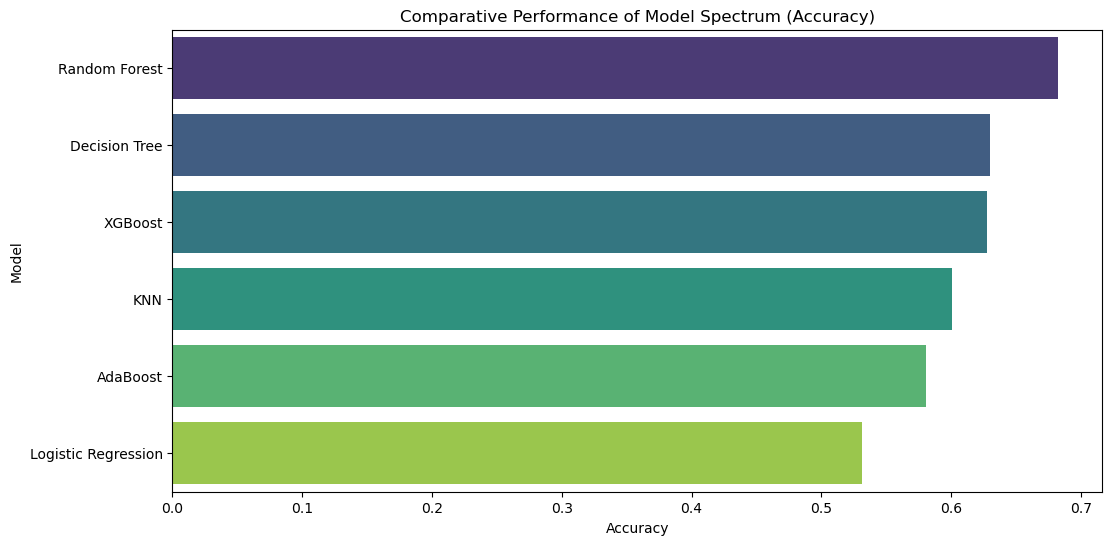

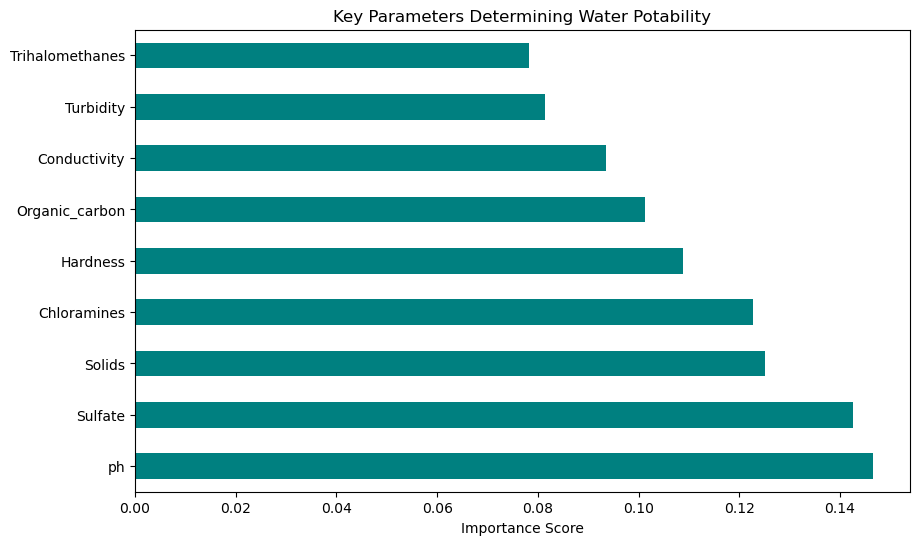

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, auc)
import warnings

warnings.filterwarnings('ignore')

# 1. DATA PREPARATION (Missing values handled by dropping rows)
df = pd.read_csv("water_potability.csv")
df_cleaned = df.dropna()

X = df_cleaned.drop("Potability", axis=1)
y = df_cleaned["Potability"]

# 2. SPLIT AND SCALING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. SMOTE (Original Contribution for Class Imbalance)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 4. MODEL DEFINITIONS AND OPTIMIZATION
model_params = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {'solver': ['liblinear', 'lbfgs']}
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {'n_neighbors': [3, 5, 7, 9], 'leaf_size': [1, 5, 10]}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {'criterion': ['gini', 'entropy'], 'min_samples_leaf': [1, 2, 4]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [100, 300], 'min_samples_split': [2, 5]}
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {'n_estimators': [100, 300], 'learning_rate': [0.1, 0.5, 1.0]}
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "params": {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1, 0.2]},
        "use_random": True 
    }
}

# 5. TRAINING AND VISUALIZATION (Confusion Matrix & ROC)
results_list = []
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 12)) # Height increased to 12
axes_cm = axes_cm.flatten()

plt.figure(figsize=(10, 8)) # ROC Figure
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange']

for i, (name, mp) in enumerate(model_params.items()):
    print(f"{name} is being optimized...")
    
    if mp.get("use_random"):
        search = RandomizedSearchCV(mp['model'], mp['params'], n_iter=5, cv=5, random_state=42)
    else:
        search = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy')
    
    search.fit(X_train_res, y_train_res)
    best_clf = search.best_estimator_
    y_pred = best_clf.predict(X_test_scaled)
    y_prob = best_clf.predict_proba(X_test_scaled)[:, 1]
    
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

    # Confusion Matrix - Adjusted with subplots_adjust to prevent overlap
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i])
    axes_cm[i].set_title(f"{name}\nConfusion Matrix", fontsize=12, pad=10)
    axes_cm[i].set_xlabel("Predicted")
    axes_cm[i].set_ylabel("Actual")
    
    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# 6. FINAL PLOTS AND TABLE
# Adjust spacing specifically for Confusion Matrix Grid
fig_cm.subplots_adjust(hspace=0.4, wspace=0.3) # hspace added to push bottom row down

# ROC Curve Plot
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.title('Comparison of ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Performance Table (Without Best Params)
results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)
display(results_df)

# Accuracy Comparison Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Comparative Performance of Model Spectrum (Accuracy)")
plt.show()

# Key Parameters (Feature Importance)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_clf.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Key Parameters Determining Water Potability")
plt.xlabel("Importance Score")
plt.show()

# Show Adjusted Confusion Matrices
plt.show()